In [6]:
import os, csv

number_of_pockets_p2rank = []
number_of_predicted_proteins_p2rank = 0

for file in os.listdir('/media/drive1/g2p_data/data_releases/2026_03/processed_data/p2rank_features_by_gene_2026_q1'):
    if not file.endswith('.txt'):
        continue
    with open(os.path.join('/media/drive1/g2p_data/data_releases/2026_03/processed_data/p2rank_features_by_gene_2026_q1', file), 'r') as f:
        reader = csv.reader(f, delimiter='\t')
        header = next(reader)
        max_pocket_number = 0
        for row in reader:
            if row[3] == '':
                continue
            pocket_number = int(row[3])
            if pocket_number > max_pocket_number:
                max_pocket_number = pocket_number
    number_of_pockets_p2rank.append(max_pocket_number)
    number_of_predicted_proteins_p2rank += 1

print(f'Total number of pockets: {sum(number_of_pockets_p2rank)}')
print(f'Total number of predicted proteins: {number_of_predicted_proteins_p2rank}')
print(f'Average number of pockets per predicted protein: {sum(number_of_pockets_p2rank) / number_of_predicted_proteins_p2rank:.2f}')

Total number of pockets: 156028
Total number of predicted proteins: 23713
Average number of pockets per predicted protein: 6.58


In [7]:
import os, csv

number_of_pockets_af2bind = []
number_of_predicted_proteins_af2bind = 0

for file in os.listdir('/media/drive1/g2p_data/data_releases/2026_03/processed_data/af2bind_features_by_gene_2026_q1'):
    if not file.endswith('.csv'):
        continue
    with open(os.path.join('/media/drive1/g2p_data/data_releases/2026_03/processed_data/af2bind_features_by_gene_2026_q1', file), 'r') as f:
        reader = csv.reader(f, delimiter='\t')
        header = next(reader)
        max_pocket_number = 0
        for row in reader:
            if row[3] == '':
                continue
            pocket_number = int(row[3])
            if pocket_number > max_pocket_number:
                max_pocket_number = pocket_number
    number_of_pockets_af2bind.append(max_pocket_number)
    number_of_predicted_proteins_af2bind += 1

print(f'Total number of pockets: {sum(number_of_pockets_af2bind)}')
print(f'Total number of predicted proteins: {number_of_predicted_proteins_af2bind}')
print(f'Average number of pockets per predicted protein: {sum(number_of_pockets_af2bind) / number_of_predicted_proteins_af2bind:.2f}')

Total number of pockets: 20125
Total number of predicted proteins: 13554
Average number of pockets per predicted protein: 1.48


P2Rank: n=23713, total pockets=156028, mean=6.58, median=4
AF2Bind: n=13554, total pockets=20125, mean=1.48, median=1
Saved pocket_distribution.pdf / .png


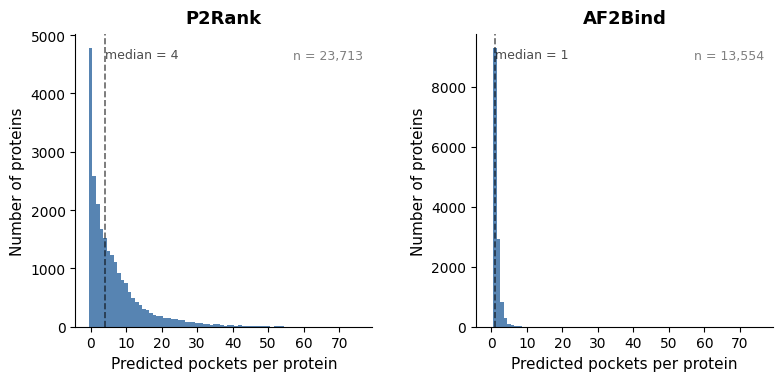

In [8]:
"""
Reads precomputed pocket data directly from the P2Rank and AF2Bind feature
directories. No CSV input needed — just update the two directory paths below.
 
P2Rank files: TSV with a header row; pocket number is in column index 3 (int).
              Rows with empty column 3 are skipped.
AF2Bind files: same format, different directory.
"""
 
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
 
# --- config: update paths as needed ---
P2RANK_DIR  = "/media/drive1/g2p_data/data_releases/2026_03/processed_data/p2rank_features_by_gene_2026_q1"
AF2BIND_DIR = "/media/drive1/g2p_data/data_releases/2026_03/processed_data/af2bind_features_by_gene_2026_q1"
 
 
def collect_pocket_counts(directory):
    counts = []
    for filename in os.listdir(directory):
        max_pocket = 0
        with open(os.path.join(directory, filename)) as f:
            reader = csv.reader(f, delimiter="\t")
            next(reader)  # skip header
            for row in reader:
                if row[3] == "":
                    continue
                pocket_number = int(row[3])
                if pocket_number > max_pocket:
                    max_pocket = pocket_number
        counts.append(max_pocket)
    return counts
 
 
p2rank_counts  = collect_pocket_counts(P2RANK_DIR)
af2bind_counts = collect_pocket_counts(AF2BIND_DIR)
 
for label, counts in [("P2Rank", p2rank_counts), ("AF2Bind", af2bind_counts)]:
    print(f"{label}: n={len(counts)}, total pockets={sum(counts)}, "
          f"mean={sum(counts)/len(counts):.2f}, median={int(np.median(counts))}")
 
# --- plot ---
max_val = max(max(p2rank_counts), max(af2bind_counts))
bins = np.arange(0, max_val + 2) - 0.5
 
ACCENT = "#3A6EA5"   # swap for deck accent color
 
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=False)
fig.subplots_adjust(wspace=0.35)
 
for ax, counts, label in zip(
    axes,
    [p2rank_counts, af2bind_counts],
    ["P2Rank", "AF2Bind"],
):
    ax.hist(counts, bins=bins, color=ACCENT, alpha=0.85, linewidth=0)
 
    median = int(np.median(counts))
    ax.axvline(median, color="black", linewidth=1.2, linestyle="--", alpha=0.6)
    ax.text(
        median + 0.15, ax.get_ylim()[1] * 0.92,
        f"median = {median}",
        fontsize=9, color="black", alpha=0.7,
    )
 
    ax.set_title(label, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Predicted pockets per protein", fontsize=11)
    ax.set_ylabel("Number of proteins", fontsize=11)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=10)
    ax.text(
        0.97, 0.95, f"n = {len(counts):,}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="gray",
    )
 
plt.savefig("pocket_distribution.pdf", bbox_inches="tight", dpi=300)
plt.savefig("pocket_distribution.png", bbox_inches="tight", dpi=300)
print("Saved pocket_distribution.pdf / .png")
 


In [4]:
import os

uniprot_ids = set()
for file in os.listdir('/media/drive1/g2p_data/data_releases/2026_03/processed_data/p2rank_features_by_gene_2026_q1'):
    if not file.endswith('.txt'):
        continue
    uniprot_ids.add(file.split('-')[1])
print(len(uniprot_ids))

20677
